<a href="https://colab.research.google.com/github/Moussaoui-Ghiles/Pytorch/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
%matplotlib inline
import torchvision.transforms as transforms
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F


In [ ]:
# Download training dataset
dataset = MNIST(root='data/', download=True)
# Test Dataset
test_dataset = MNIST(root='data/', train=False)

Label: 5


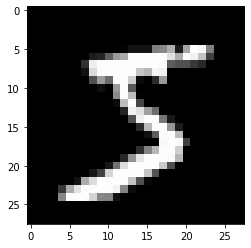

In [3]:
image, label = dataset[0]
plt.imshow(image, cmap='gray')
print('Label:', label)

In [4]:
# MNIST dataset (images and labels)
dataset = MNIST(root='data/', 
                train=True,
                transform=transforms.ToTensor())

In [5]:
# Training and validation data 


train_ds, val_ds = random_split(dataset, [50000, 10000])
len(train_ds), len(val_ds)

(50000, 10000)

In [6]:
# Load the data
from torch.utils.data import DataLoader

batch_size = 128

train_loader = DataLoader(train_ds, batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size)

In [7]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [8]:
# Model

input_size = 28*28
num_classes = 10

class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)
        
    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        out = self.linear(xb)
        return out
    
    def training_step(self, batch):
        images, labels = batch 
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
    
    def validation_step(self, batch):
        images, labels = batch 
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss, 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result['val_loss'], result['val_acc']))
    
model = MnistModel()

In [9]:
def evaluate(model, val_loader):
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

In [10]:
def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    optimizer = opt_func(model.parameters(), lr)
    history = [] # for recording epoch-wise results
    
    for epoch in range(epochs):
        
        # Training Phase 
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        
        # Validation phase
        result = evaluate(model, val_loader)
        model.epoch_end(epoch, result)
        history.append(result)

    return history

In [11]:
result0 = evaluate(model, val_loader)
result0


{'val_loss': 2.3366355895996094, 'val_acc': 0.07199367135763168}

In [12]:
history1 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 1.9639, val_acc: 0.5969
Epoch [1], val_loss: 1.6900, val_acc: 0.7257
Epoch [2], val_loss: 1.4858, val_acc: 0.7645
Epoch [3], val_loss: 1.3320, val_acc: 0.7826
Epoch [4], val_loss: 1.2137, val_acc: 0.7966


In [13]:
history2 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 1.1210, val_acc: 0.8061
Epoch [1], val_loss: 1.0467, val_acc: 0.8127
Epoch [2], val_loss: 0.9859, val_acc: 0.8183
Epoch [3], val_loss: 0.9354, val_acc: 0.8231
Epoch [4], val_loss: 0.8929, val_acc: 0.8298


In [14]:
history3 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 0.8564, val_acc: 0.8321
Epoch [1], val_loss: 0.8250, val_acc: 0.8353
Epoch [2], val_loss: 0.7974, val_acc: 0.8374
Epoch [3], val_loss: 0.7731, val_acc: 0.8401
Epoch [4], val_loss: 0.7515, val_acc: 0.8421


In [15]:
history4 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 0.7321, val_acc: 0.8448
Epoch [1], val_loss: 0.7147, val_acc: 0.8473
Epoch [2], val_loss: 0.6988, val_acc: 0.8486
Epoch [3], val_loss: 0.6844, val_acc: 0.8497
Epoch [4], val_loss: 0.6712, val_acc: 0.8521


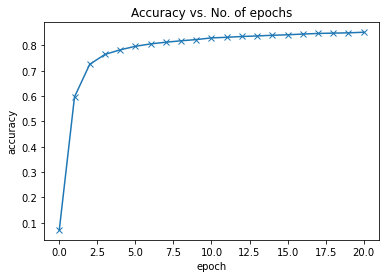

In [16]:
history = [result0] + history1 + history2 + history3 + history4
accuracies = [result['val_acc'] for result in history]
plt.plot(accuracies, '-x')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy vs. No. of epochs');